[2026-07-24 16:48:13] [info     ] 计算因子，区间：2022-01-01 00:00:00 ~ 2022-12-31 23:59:59


[2026-07-24 16:57:19] [info     ] 读取因子库，区间：2022-01-01 00:00:00 ~ 2022-12-31 23:59:59
[2026-07-24 16:57:19] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-24 16:57:22] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-24 16:57:22] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-24 16:57:22] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2022-01-04 至 2022-12-30
[2026-07-24 16:57:22] [info     ] ========== 数据检查 ==========
[2026-07-24 16:57:22] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset


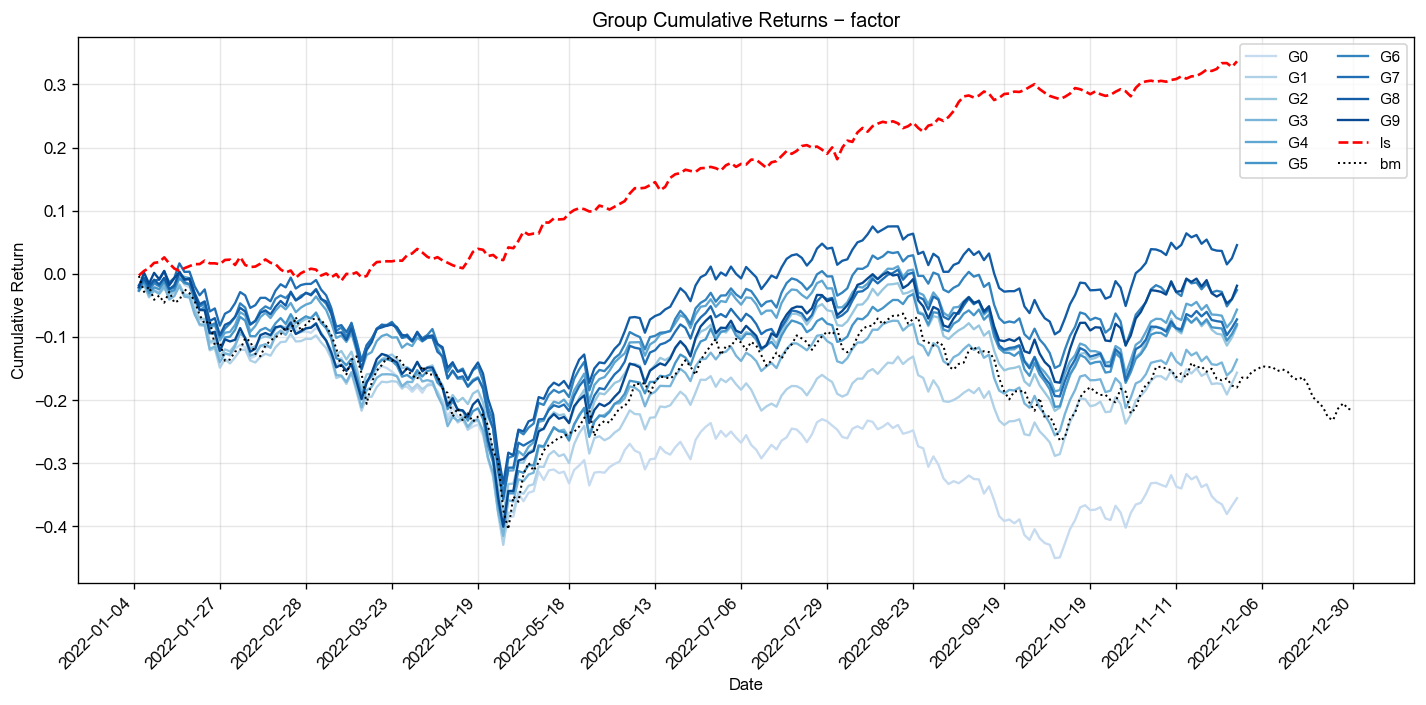
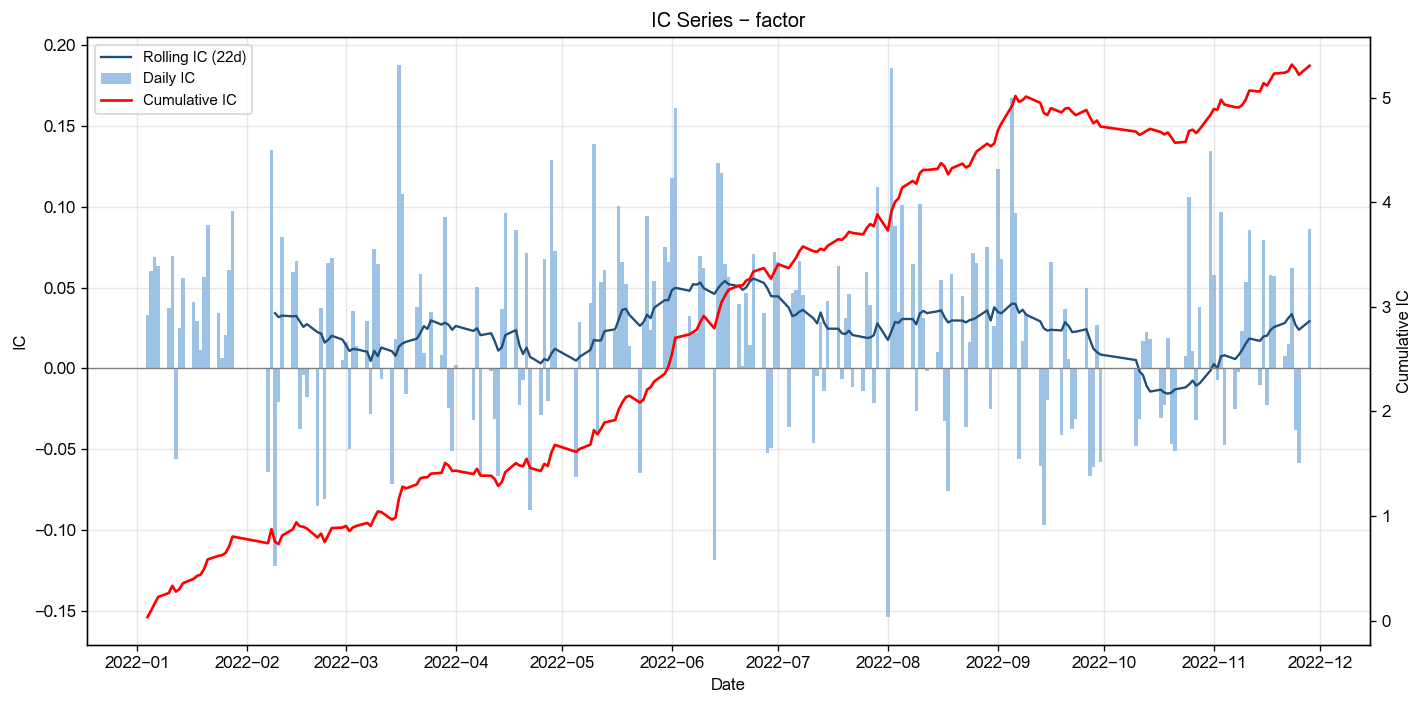
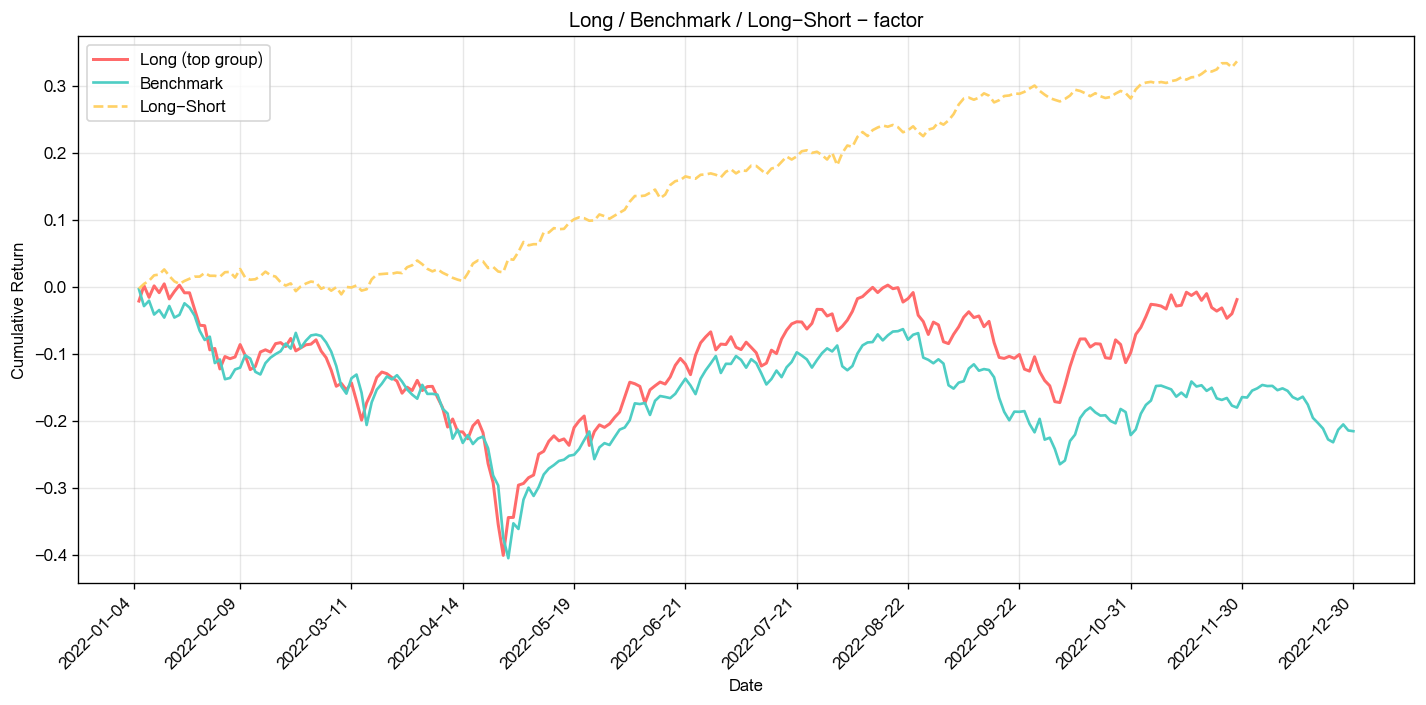

[2026-07-24 16:57:51] [info     ] ========== 因子池回归 ==========
[2026-07-24 16:57:51] [info     ] 加载 T+1 收益数据完成                  end_date=2022-12-30 instrument_count=1200 rows=295353 start_date=2022-01-04
[2026-07-24 16:57:52] [info     ] 获取收益率数据, 耗时: 0.9286 秒
[2026-07-24 16:57:53] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.264 秒
[2026-07-24 16:57:53] [info     ] 统计 回归结果, 耗时: 0.102 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.5280,0.0121,0.0048,1.0000
2,turn,2.2804,0.0339,0.0149,1.0000
3,volatility_5,2.0318,0.0174,0.0086,1.0000
4,volume,1.9990,0.0239,0.0119,1.0000
5,beta_000300SH_22,1.8379,0.0228,0.0124,1.0000
6,cci_14,1.8199,0.0286,0.0157,1.0000
7,macd_dea_12_26_9,1.6929,0.0156,0.0092,0.9000
8,net_profit_rate_ttm,1.6818,0.0076,0.0045,1.0000
9,net_active_buy_amount_main,1.6498,0.0147,0.0089,1.0000
10,amount,1.6157,0.0196,0.0122,1.0000

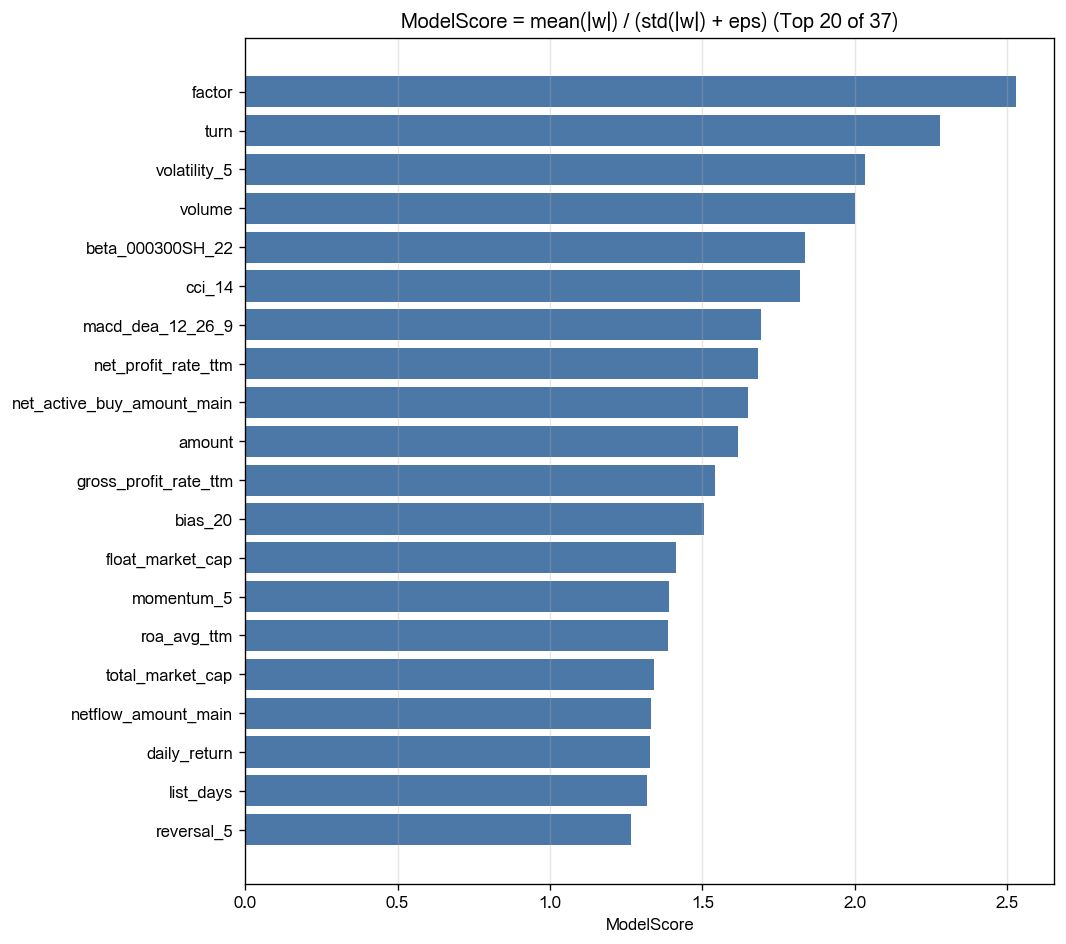
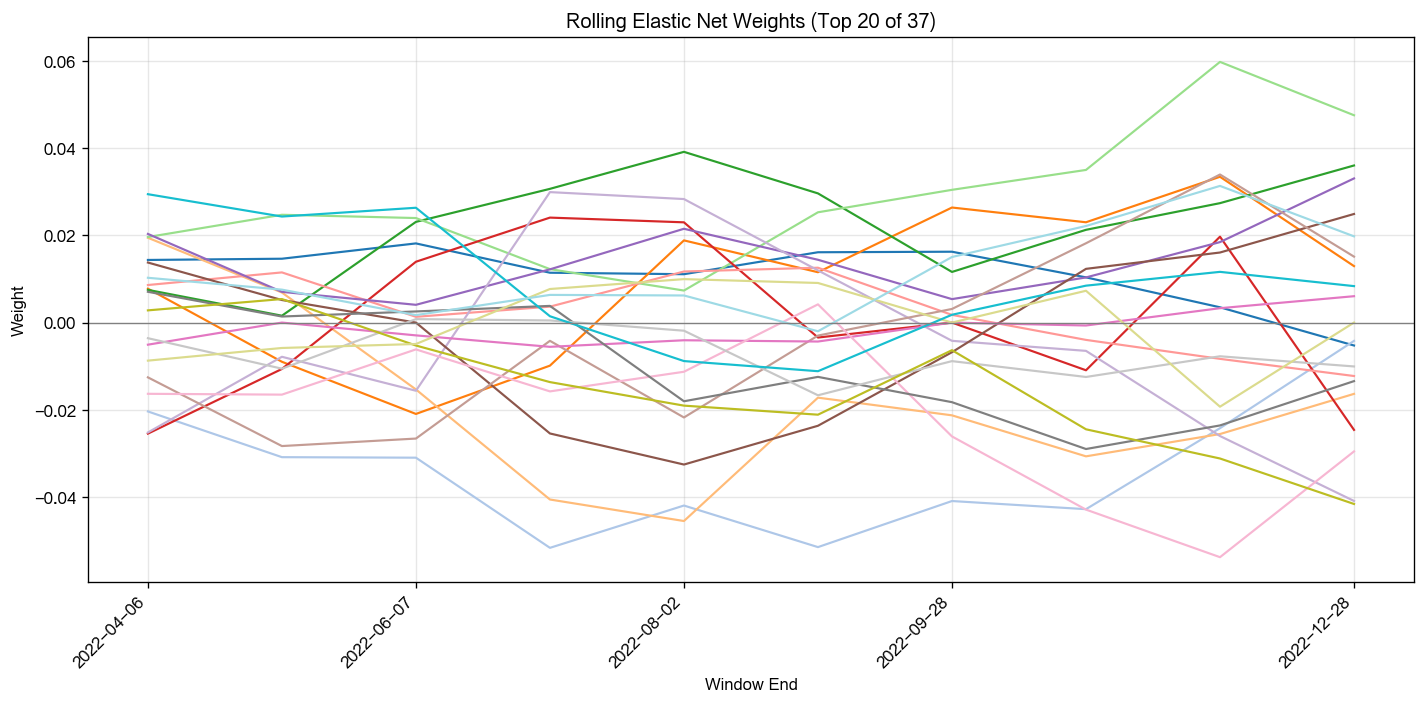
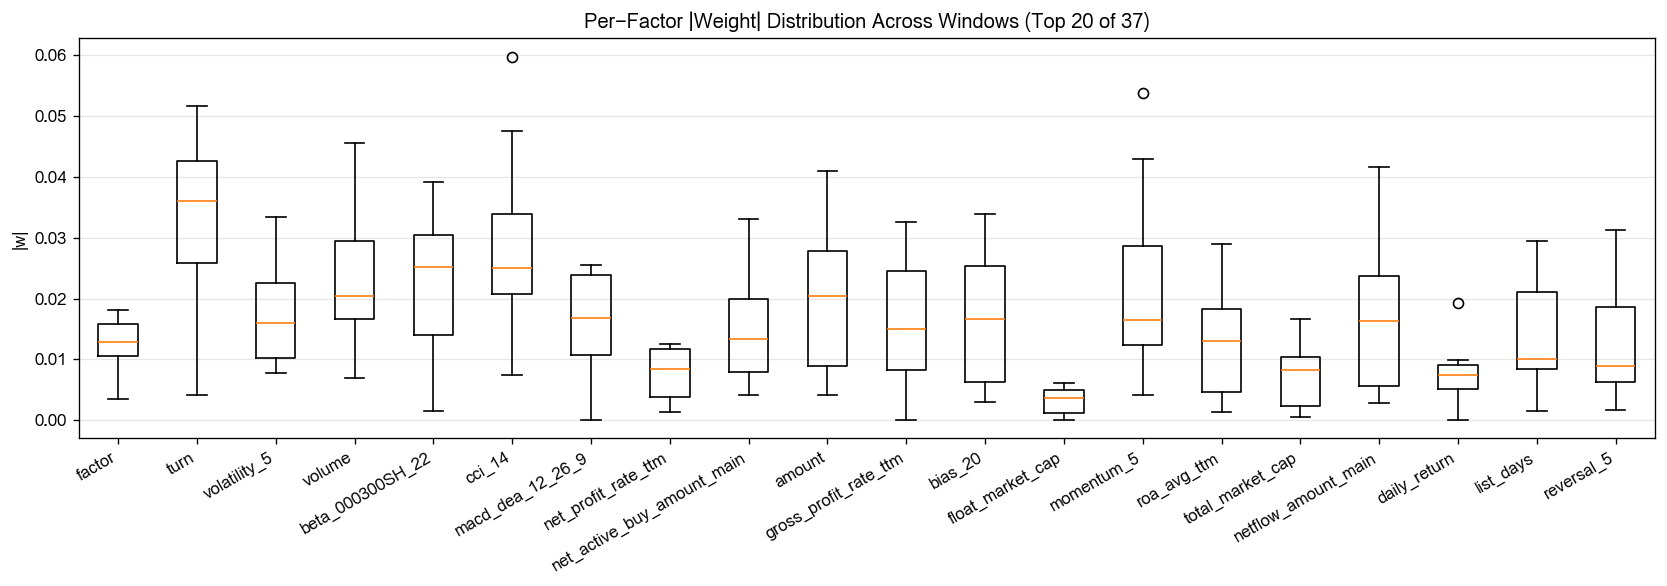
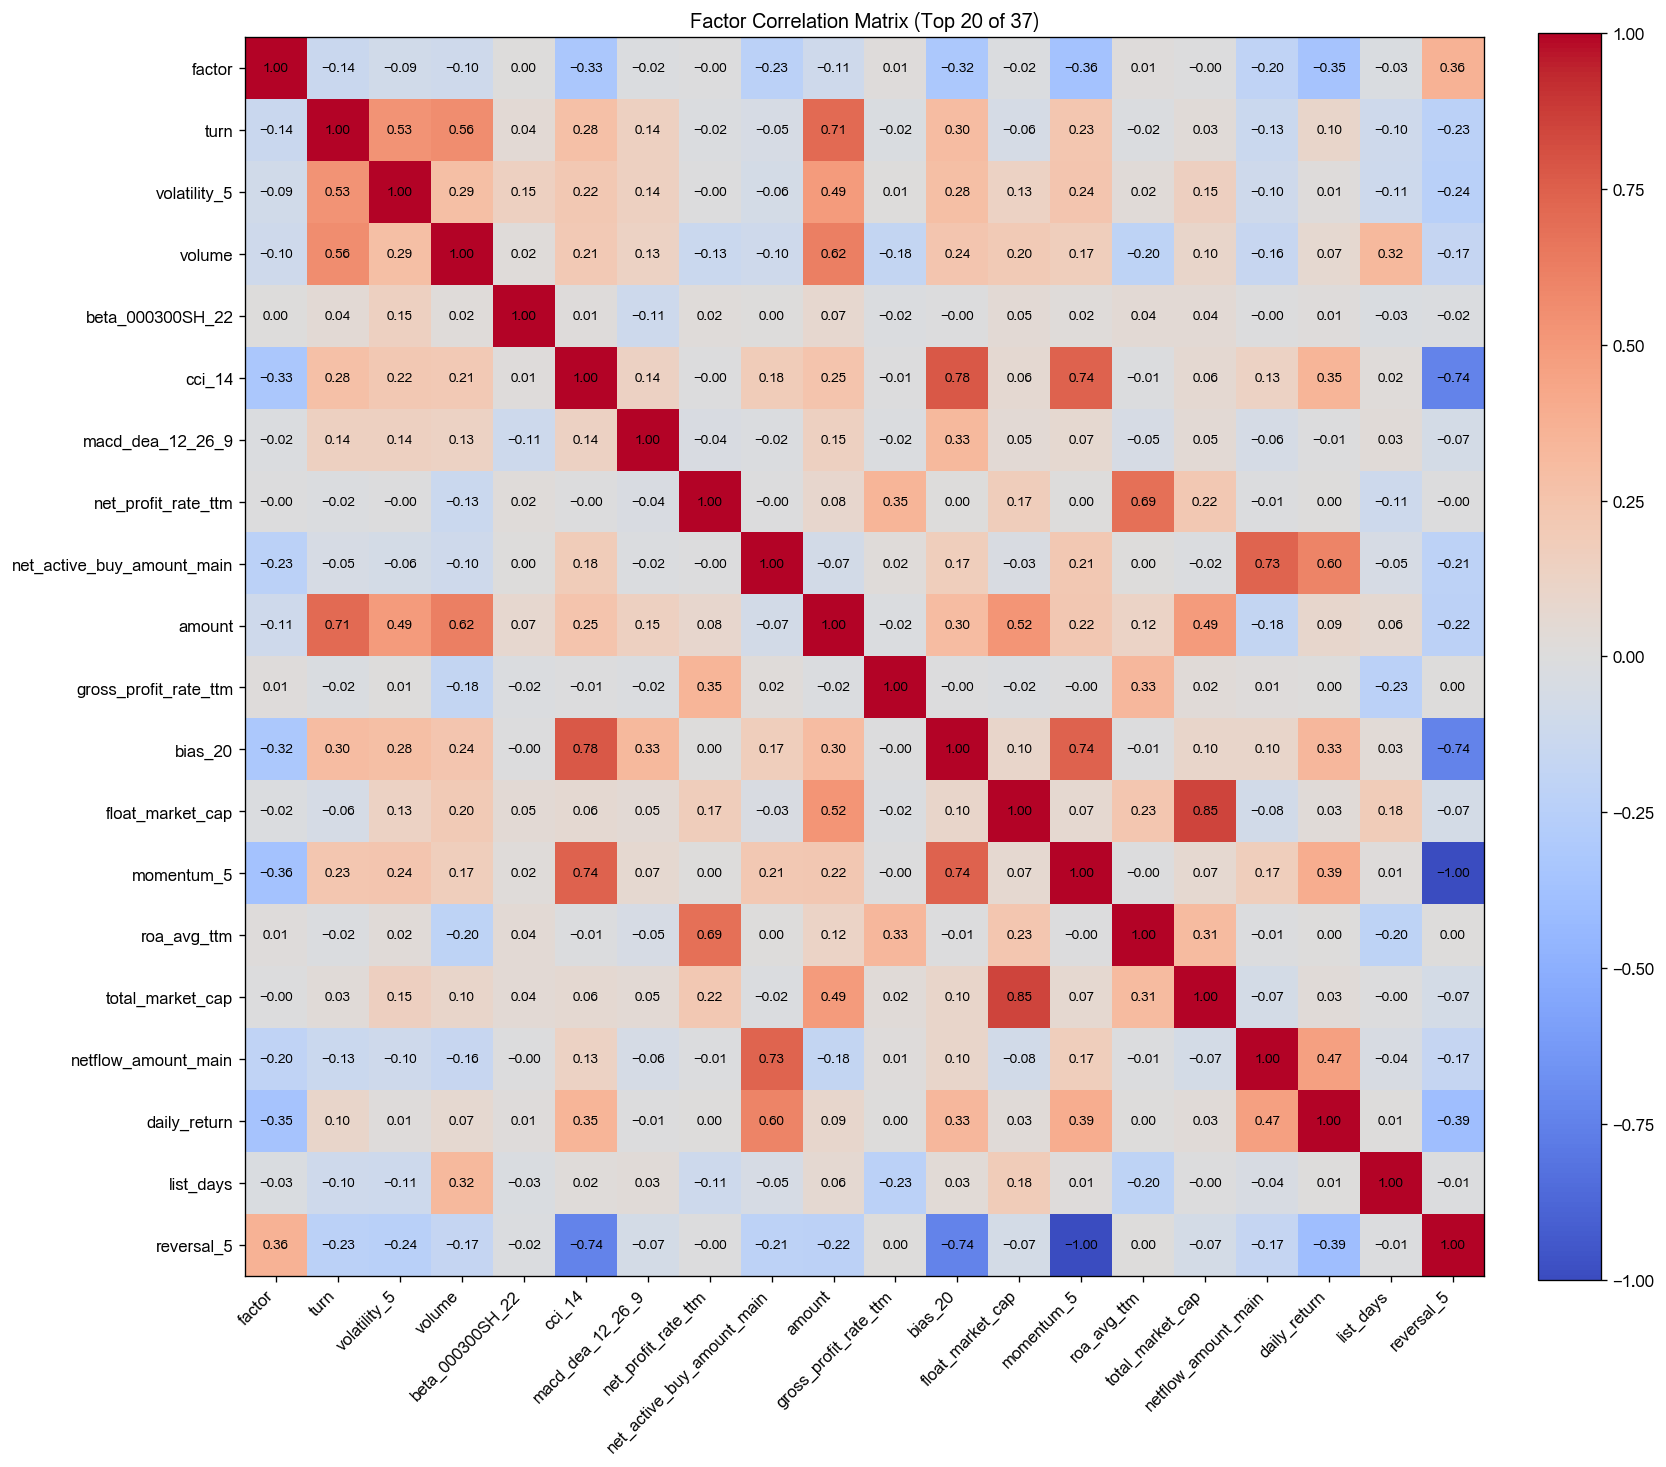

[2026-07-24 16:57:56] [warning  ] 返回的Outputs实例(size=35314051) 大于 64K, 将不会被缓存
[2026-07-24 16:57:56] [info     ] bigalpha_eval.v4 运行完成 [34.210s].


In [3]:
def main(datasources, start_date, end_date):
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]
    LOOKBACK = 90
    bar_start = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK)).strftime('%Y-%m-%d')

    # =================== Part 1: 日内低效率反转 ===================
    ineff_sql = f"""
    WITH minute_data AS (
        SELECT date, instrument,
            strftime(date, '%Y-%m-%d') AS trading_day,
            (ask_price1 + bid_price1) / 2.0 AS mid_price
        FROM {bar1m}
        WHERE ask_price1 > 0 AND bid_price1 > 0
    ),
    ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (PARTITION BY instrument, trading_day ORDER BY date) AS rn1,
            ROW_NUMBER() OVER (PARTITION BY instrument, trading_day ORDER BY date DESC) AS rn2,
            ABS(mid_price / LAG(mid_price) OVER (PARTITION BY instrument, trading_day ORDER BY date) - 1.0) AS abs_ret
        FROM minute_data
    ),
    daily AS (
        SELECT trading_day, instrument,
            SUM(abs_ret) AS path_ret,
            MAX(CASE WHEN rn1 = 1 THEN mid_price END) AS day_open,
            MAX(CASE WHEN rn2 = 1 THEN mid_price END) AS day_close,
            COUNT(*) AS bar_cnt
        FROM ranked
        GROUP BY trading_day, instrument
    )
    SELECT CAST(trading_day AS DATETIME) AS date, instrument,
        CASE WHEN bar_cnt >= 30 AND day_open > 0 AND day_close > 0
            THEN path_ret - ABS(day_close / day_open - 1.0)
            ELSE NULL END AS inefficiency,
        CASE WHEN day_open > 0 AND day_close > 0
            THEN day_close / day_open - 1.0
            ELSE NULL END AS day_ret
    FROM daily
    """
    df_ineff = dai.query(ineff_sql, filters={'date': [bar_start, end_date]}, compression=True).df()
    df_ineff['date'] = pd.to_datetime(df_ineff['date'])

    # =================== Part 2: 已实现偏度 ===================
    skew_sql = f"""
    WITH bar AS (
        SELECT strftime(date, '%Y-%m-%d') AS trading_day, instrument, close,
            LAG(close) OVER (PARTITION BY instrument, strftime(date, '%Y-%m-%d') ORDER BY date) AS prev_close
        FROM {bar1m}
        WHERE close > 0
    ),
    rets AS (
        SELECT trading_day, instrument, LN(close / prev_close) AS r
        FROM bar
        WHERE prev_close > 0 AND prev_close IS NOT NULL
            AND close / prev_close BETWEEN 0.5 AND 2.0
    )
    SELECT trading_day, instrument,
        COUNT(r) AS n, SUM(r * r) AS rv, SUM(r * r * r) AS m3
    FROM rets
    GROUP BY trading_day, instrument
    HAVING COUNT(r) >= 200 AND SUM(r * r) > 1e-10
    """
    df_skew = dai.query(skew_sql, filters={'date': [bar_start, end_date]}, compression=True).df()
    df_skew['date'] = pd.to_datetime(df_skew['trading_day'].astype(str))
    n = df_skew['n'].astype(float)
    df_skew['RS'] = np.sqrt(n) * df_skew['m3'] / (df_skew['rv'] ** 1.5 + 1e-12)

    def winsorize(df, col, q=0.01):
        lo = df.groupby('date')[col].transform(lambda x: x.quantile(q))
        hi = df.groupby('date')[col].transform(lambda x: x.quantile(1 - q))
        return df[col].clip(lower=lo, upper=hi)

    df_skew['RS_w'] = winsorize(df_skew, 'RS')
    df_skew = df_skew.sort_values(['instrument', 'date'])
    df_skew['RS_ema5'] = df_skew.groupby('instrument')['RS_w'].transform(
        lambda x: x.ewm(span=5, min_periods=1).mean()
    )
    df_skew = df_skew[['date', 'instrument', 'RS_ema5', 'rv']]

    # =================== Part 3: 合并与原始信号 ===================
    df = pd.merge(df_ineff, df_skew, on=['date', 'instrument'], how='inner')
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

    def rolling_last_pct_rank(x):
        x = np.asarray(x)
        if len(x) == 0 or not np.isfinite(x[-1]): return np.nan
        valid = x[np.isfinite(x)]
        if len(valid) < 8: return np.nan
        return np.mean(valid <= x[-1])

    df['ineff_pct_40'] = (
        df.groupby('instrument')['inefficiency']
        .rolling(window=40, min_periods=12)
        .apply(rolling_last_pct_rank, raw=True)
        .reset_index(level=0, drop=True)
    )
    df['ineff_strength'] = (df['ineff_pct_40'] - 0.5).clip(0, 0.5) * 2.0
    df['day_ret'] = df['day_ret'].clip(-0.12, 0.12)
    df['ret_direction'] = np.sign(df['day_ret'])
    df['ret_strength'] = np.sqrt(np.abs(df['day_ret']))
    df['ineff_signal'] = -1.0 * df['ret_direction'] * df['ret_strength'] * df['ineff_strength']
    df['skew_signal'] = -df['RS_ema5']

    # =================== Part 4: 行业数据 ===================
    ind_df = dai.query(
        "SELECT date, instrument, industry_level1_code FROM bigalpha_2026_exposure",
        filters={'date': [start_date, end_date]}
    ).df()
    ind_df['date'] = pd.to_datetime(ind_df['date'].astype(str))
    df = pd.merge(df, ind_df, on=['date', 'instrument'], how='left')
    df['industry_level1_code'] = df['industry_level1_code'].fillna('unknown')

    # =================== Part 5: 正交偏度信号（稳健版） ===================
    def orthogonalize_skew(grp):
        # 只用两个信号都非 NaN 的样本
        valid = grp['ineff_signal'].notna() & grp['skew_signal'].notna()
        if valid.sum() < 10:
            return grp['skew_signal'] - grp['skew_signal'].mean()
        X = np.c_[np.ones(valid.sum()), grp.loc[valid, 'ineff_signal'].values]
        y = grp.loc[valid, 'skew_signal'].values
        try:
            beta = np.linalg.lstsq(X, y, rcond=None)[0]
        except np.linalg.LinAlgError:
            # SVD 不收敛时退回伪逆
            beta = np.linalg.pinv(X) @ y
        resid = y - X @ beta
        out = pd.Series(np.nan, index=grp.index)
        out[valid] = resid
        return out

    df['orth_skew'] = df.groupby(['date', 'industry_level1_code'], group_keys=False).apply(orthogonalize_skew)

    # =================== Part 6: 截面 z-score ===================
    def cross_zscore(frame, col, group):
        mean = frame.groupby(['date', group])[col].transform('mean')
        std  = frame.groupby(['date', group])[col].transform('std')
        return (frame[col] - mean) / (std + 1e-8)

    df['ineff_z'] = cross_zscore(df, 'ineff_signal', 'industry_level1_code')
    df['orth_skew_z'] = cross_zscore(df, 'orth_skew', 'industry_level1_code')

    # =================== Part 7: 动态权重（滚动 IC） ===================
    def daily_ic(grp, col):
        return grp[col].corr(grp['day_ret'], method='spearman')

    ic_ineff = df.groupby('date').apply(lambda x: daily_ic(x, 'ineff_z'))
    ic_skew  = df.groupby('date').apply(lambda x: daily_ic(x, 'orth_skew_z'))
    ic_df = pd.DataFrame({'ic_ineff': ic_ineff, 'ic_skew': ic_skew}).sort_index()

    ic_roll = ic_df.rolling(60, min_periods=20).mean().shift(1)
    ic_roll['skew_ratio'] = (
        ic_roll['ic_skew'].clip(lower=0) /
        (ic_roll['ic_ineff'].clip(lower=0) + ic_roll['ic_skew'].clip(lower=0) + 1e-8)
    )
    ic_roll['skew_ratio'] = ic_roll['skew_ratio'].fillna(0.5)

    df = df.merge(ic_roll[['skew_ratio']], on='date', how='left')
    df['skew_ratio'] = df['skew_ratio'].fillna(0.5)
    df['w_skew'] = df['skew_ratio'].clip(0.2, 0.6)

    # =================== Part 8: 合成因子 ===================
    df['factor_raw'] = (1 - df['w_skew']) * df['ineff_z'] + df['w_skew'] * df['orth_skew_z']
    df['factor_raw'] = cross_zscore(df, 'factor_raw', 'industry_level1_code')

    df = df[df['date'] >= pd.to_datetime(start_date)].copy()
    df = df.sort_values(['instrument', 'date'])
    df['factor'] = df.groupby('instrument')['factor_raw'].transform(
        lambda x: x.ewm(span=3, min_periods=1).mean()
    )

    result = df[['date', 'instrument', 'factor']].dropna()
    result = result[np.isfinite(result['factor'])]

    # =================== Part 9: 对齐股票池 ===================
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]}
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'].astype(str))

    final = pd.merge(stk_pool, result, how='left', on=['date', 'instrument'])
    final = pd.merge(final, ind_df, on=['date', 'instrument'], how='left')
    final['industry_level1_code'] = final['industry_level1_code'].fillna('unknown')

    ind_median  = final.groupby(['date', 'industry_level1_code'])['factor'].transform('median')
    date_median = final.groupby('date')['factor'].transform('median')

    final['factor'] = (
        final['factor']
        .fillna(ind_median)
        .fillna(date_median)
        .fillna(0.0)
    )
    final = final[np.isfinite(final['factor'])]
    return final[['date', 'instrument', 'factor']]

if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
    }
    start_date = "2022-01-01 00:00:00"
    end_date   = "2022-12-31 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )